# Vertical Profile Interpolation: Cycle-Level Spline Representation

This notebook develops a compact, queryable spline representation for individual Argo depth profiles.

**Core question**: Can we compress each profile (~80 observations per cycle for most Argo floats) into a smooth model that captures large-scale vertical structure, provides uncertainty estimates at arbitrary pressures, and serves as input to spatio-temporal modeling?

**Approach**: Adaptive B-spline fitting with curvature-guided knot placement (Li et al., 2005), LSQ rather than exact interpolation for noise robustness, and depth-varying uncertainty from sensor specs and pressure-propagated gradients (Wong et al., 2025).

**Context**: This builds on Yarger et al. (2022)'s functional representation approach but uses 9-16 adaptive knots per cycle versus 200 equispaced knots. Unlike exact interpolants like MRST-PCHIP (Barker & McDougall, 2020), this optimizes for compact representation rather than SA-CT diagram preservation.

**Scope**: This notebook demonstrates the method on 469 cycles from one subtropical region (2011, North Atlantic). It establishes proof-of-concept and baseline validation metrics. Regional generalization, failure mode analysis, and comparative benchmarking are future work.

## 1. Dependencies

In [1]:
from argopy import DataFetcher as ArgoDataFetcher
import pandas as pd
from tqdm.auto import tqdm
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
from argo_interp.cycle import CycleError, ModelError, CycleSettings, CycleModel

from argo_interp.cycle import build_model, calc_fold_error

## 2. Data Acquisition

Request Argo profiles from a bounded region and time window. This slice provides a reproducible working dataset while tuning interpolation parameters.

**Regional context**: This subtropical box (20-30°N, 75-45°W) provides relatively well-behaved profiles with clear thermoclines and stable deep layers—a good starting point for method development. Performance in challenging regimes (deep winter mixed layers, equatorial inversions, polar haloclines) remains to be validated.

In [3]:
box = [
    -75, -45, ## Longitude min/max
    20, 30, ## Latitude min/max
    0, 3000, ## Pressure/depth min/max
    '2011-01', '2011-06', ## Datetime min/max
]
f = ArgoDataFetcher().region(box).load()
data = f.data.to_dataframe()

## 3. Profile Structure

Transform flat observation rows into cycle-indexed profiles:
- Unique cycle identifier (`PLATFORM_CYCLE`)
- Cycle metadata (position, time)
- Pressure-sorted readings for model fitting

In [4]:
group_col = 'PLATFORM_CYCLE'
group_fields = ['PLATFORM_NUMBER', 'CYCLE_NUMBER']
cycle_fields = ['LATITUDE', 'LONGITUDE', 'TIME']
reading_fields = ['PRES', 'PRES_ERROR', 'PSAL', 'PSAL_ERROR', 'TEMP', 'TEMP_ERROR']

In [5]:
cycles = data[group_fields + cycle_fields].drop_duplicates().sort_values(group_fields)
cycles.index = (cycles[group_fields[0]].astype(str) + '-' + cycles[group_fields[1]].astype(str)).rename('PLATFORM_CYCLE')

In [6]:
readings = data[group_fields + reading_fields].drop_duplicates().sort_values([*group_fields, 'PRES']).reset_index(drop=True)
readings.insert(0, group_col, readings[group_fields[0]].astype(str) + '-' + readings[group_fields[1]].astype(str))
readings = readings.drop(columns=group_fields)

## 4. Cycle-Level Model Fitting

For each profile:
1. Estimate validation error via 5-fold cross-validation
2. Fit temperature and salinity spline models
3. Package models with error estimates in `CycleModel` objects

The result: a compact library where you provide a cycle ID and pressure, and get back interpolated values with uncertainty.

### Method Overview

Ocean profiles have mixed structure: thermoclines bend sharply, deep layers are flat. Rather than spreading knots uniformly, place them where curvature is highest—more in the thermocline, fewer in the abyss. This follows curvature-adaptive spline fitting principles from Li et al. (2005).

Use least-squares fitting rather than exact interpolation. Traditional methods (like MRST-PCHIP) are forced through every observation, which can overfit to sensor noise and make interpolated values between observations less reliable. LSQ fitting finds the smooth curve that best represents all observations collectively, averaging down noise.

Uncertainty comes from three sources (Wong et al., 2025): pressure sensor (2.4 dbar), temperature sensor (0.002°C), and salinity (0.01 PSU floor). Total uncertainty varies with depth because pressure error propagates through vertical gradients: |dT/dP| × 2.4 dbar matters in the thermocline, vanishes in the flat deep ocean.

This method uses 9-16 knots per cycle (median ~9) versus Yarger et al.'s (2022) 200 equispaced knots.

### Parameter Choices

The `CycleSettings` used here (`prominence=0.25, window=10, spacing=5.0, peak_dist=20, folds=5`) were selected through informal experimentation on a subset of profiles. These values are likely region-specific and not necessarily optimal. 

Parameters can be tuned to achieve tighter fits if needed, though this increases knot count and compromises storage efficiency. The trade-off between representation fidelity and model compactness is application-dependent. Systematic parameter tuning and sensitivity analysis are planned future work.

In [7]:
settings = CycleSettings(
    prominence = 0.25,
    window = 10,
    spacing = 5.0,
    peak_dist = 20,
    folds = 5,
)

cycle_models = {}
for cycle_number, cycle_data in tqdm(readings.groupby('PLATFORM_CYCLE')):
    cycle_data = cycle_data.sort_values('PRES')
    rmse_temp, rmse_sal = calc_fold_error(cycle_data, settings)

    model_temp = build_model(cycle_data['PRES'], cycle_data['TEMP'], settings)
    model_sal = build_model(cycle_data['PRES'], cycle_data['PSAL'], settings)

    cycle_error = CycleError(model=ModelError(
        temperature=rmse_temp,
        salinity=rmse_sal
    ))
    cycle_model = CycleModel(
        temperature=build_model(cycle_data['PRES'], cycle_data['TEMP'], settings),
        salinity=build_model(cycle_data['PRES'], cycle_data['PSAL'], settings),
        error=cycle_error,
        settings=settings,
        pressure_bounds=(cycle_data['PRES'].min(), cycle_data['PRES'].max()),
    )
    cycle_models[cycle_number] = cycle_model

  0%|          | 0/469 [00:00<?, ?it/s]

## 5a. Single-Cycle Inspection

Select one cycle for detailed examination. Does the interpolated profile look physically reasonable point-by-point, not just in aggregate?

In [8]:
# cycle_number = np.random.choice(list(cycle_models.keys()))
cycle_number = '6900551-71'
print(f"Cycle #: {cycle_number}")
cycle_data = readings.loc[readings['PLATFORM_CYCLE'] == cycle_number]
cycle_model = cycle_models[cycle_number]

Cycle #: 6900551-71


In [9]:
cycle_interp = cycle_model.interpolate(cycle_data['PRES'])

## 5b. Uncertainty Envelope Construction

Construct plotting bands from per-point error terms. Use 2σ as a readable approximation of a likely range around each estimate (not a formal confidence interval).

**Depth-varying uncertainty**: The uncertainty envelope widens in the thermocline where |dT/dP| is large, reflecting the fact that a fixed pressure uncertainty (2.4 dbar) contributes more to temperature uncertainty where gradients are steep. In the flat deep ocean where dT/dP → 0, pressure-propagated error vanishes and only sensor noise and model residuals remain.

The three error sources (model RMSE, sensor noise, pressure-propagated gradient) are combined as root-sum-square (RSS) for each query. This assumes independent error sources, which is reasonable for these physically distinct contributions.

In [10]:
sd_offset = 2

cycle_interp['temp_low'] = (cycle_interp['temperature'] - (sd_offset * cycle_interp['temp_error']))
cycle_interp['temp_high'] = (cycle_interp['temperature'] + (sd_offset * cycle_interp['temp_error']))
cycle_interp['sal_low'] = (cycle_interp['salinity'] - (sd_offset * cycle_interp['sal_error']))
cycle_interp['sal_high'] = (cycle_interp['salinity'] + (sd_offset * cycle_interp['sal_error']))

## 5c. Visual Diagnostic

Interpolated curves with 2σ envelopes via `fill_betweenx`. Pressure increases downward. Where bands widen, the model signals greater local uncertainty.

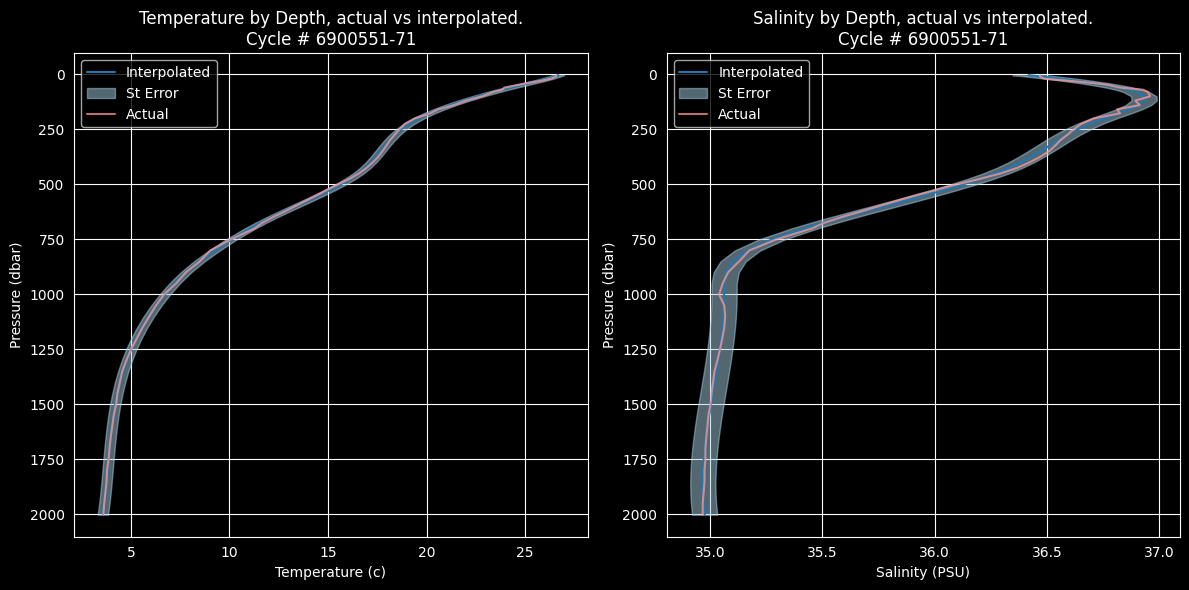

In [11]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 6))

cycle_interp.reset_index().plot(x='temperature', y='pressure', color='#1f78b4', ax=ax[0])
ax[0].fill_betweenx(y=cycle_interp.index, x1=cycle_interp['temp_low'], x2=cycle_interp['temp_high'], color='#a6cee3', alpha=0.5)
cycle_data.plot(x='TEMP', y='PRES', color='#fb9a99', alpha=0.75, ax=ax[0])
ax[0].set(
    title=f"Temperature by Depth, actual vs interpolated."
          f"\nCycle # {cycle_number}",
    xlabel=f"Temperature (c)",
    ylabel=f"Pressure (dbar)",
)
ax[0].invert_yaxis()
ax[0].legend(["Interpolated", "St Error", "Actual"])

cycle_interp.reset_index().plot(x='salinity', y='pressure', color='#1f78b4', ax=ax[1])
ax[1].fill_betweenx(y=cycle_interp.index, x1=cycle_interp['sal_low'], x2=cycle_interp['sal_high'], color='#a6cee3', alpha=0.5)
cycle_data.plot(x='PSAL', y='PRES', color='#fb9a99', alpha=0.75, ax=ax[1])
ax[1].set(
    title=f"Salinity by Depth, actual vs interpolated."
          f"\nCycle # {cycle_number}",
    xlabel=f"Salinity (PSU)",
    ylabel=f"Pressure (dbar)",
)
ax[1].invert_yaxis()
ax[1].legend(["Interpolated", "St Error", "Actual"])

fig.tight_layout()

### Interpretation

Observed profile follows interpolated profile closely across depth. Most points stay inside the 2σ envelope, indicating stable behavior with informative but not inflated uncertainty bounds.

## 6a. Cross-Cycle Validation: RMSE Distributions

If the fitting procedure is stable, validation RMSE should cluster in a low-error regime. Are we consistently accurate, or only accurate on easy cycles?

**Note**: These values quantify within-profile reconstruction error from 5-fold cross-validation, not spatio-temporal prediction error. Published benchmarks for this specific task (vertical representation accuracy) are scarce in the literature.

In [12]:
model_error = pd.DataFrame([model.error.model for model in cycle_models.values()])

In [13]:
pd.concat([
    model_error.mean().rename('mean'),
    model_error.median().rename('median'),
    model_error.std().rename('stdev'),
], axis=1)

,mean,median,stdev
temperature,0.175418,0.145589,0.099711
salinity,0.029466,0.024603,0.016469


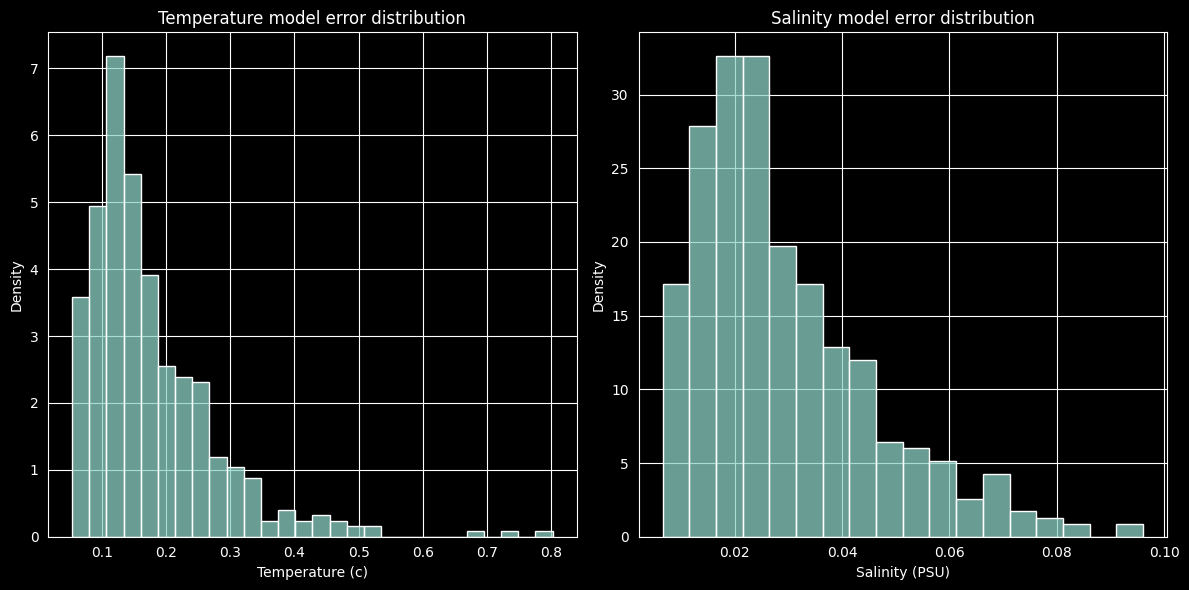

In [14]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 6))

sns.histplot(model_error['temperature'], stat='density', ax=ax[0])
ax[0].set(
    title=f"Temperature model error distribution",
    xlabel=f"Temperature (c)",
)

sns.histplot(model_error['salinity'], stat='density', ax=ax[1])
ax[1].set(
    title=f"Salinity model error distribution",
    xlabel=f"Salinity (PSU)",
)

fig.tight_layout()

### Distribution Interpretation

Both RMSE distributions are strongly right-skewed: most cycles fit well, with a smaller tail of difficult outliers. This is expected for ocean profile data. The central tendency (median temperature RMSE 0.146°C, salinity 0.025 PSU) is reasonable for current objectives. High-error tail cases are targeted follow-up tasks.

**Open question**: The right tail (some cycles with RMSE > 0.35°C) deserves investigation. Potential causes include profiles with strong subsurface inversions, fine-scale layering, or sparse sampling in complex regions. Identifying and handling high-error cases is a priority for making this method production-ready.

## 6b. Residual Structure by Depth

Validation RMSE tells us average error, but not where it occurs. Do residuals show systematic depth patterns?

**Question**: Does error correlate with oceanographic complexity? If adaptive knot placement is working, we'd expect reasonable errors in complex regions (sharp thermocline, inversions, fine-scale intrusions) that average near zero, though likely still elevated compared to simpler regimes (deep ocean, homogeneous mixed layer). Errors should reflect genuine modeling difficulty, not uniform distribution.

Note: These are pure model reconstruction residuals (0.175°C RMSE). Total reported uncertainty is larger, adding sensor error and pressure-propagated gradient terms that vary with depth.

In [15]:
error_records = []
for cycle_number, cycle_data in tqdm(readings.groupby('PLATFORM_CYCLE')):
    cycle_model = cycle_models[cycle_number]
    cycle_interp = cycle_model.interpolate(cycle_data['PRES'])
    cycle_values = pd.concat([
        cycle_data.set_index('PRES')['TEMP'].rename('temp_actual'),
        cycle_interp['temperature'].rename('temp_interp'),
        cycle_data.set_index('PRES')['PSAL'].rename('sal_actual'),
        cycle_interp['salinity'].rename('sal_interp'),
    ], axis=1).reset_index().rename(columns={'index': 'pressure'})
    cycle_values['temp_error'] = cycle_values['temp_actual'] - cycle_values['temp_interp']
    cycle_values['sal_error'] = cycle_values['sal_actual'] - cycle_values['sal_interp']
    error_records.append(cycle_values[['pressure', 'temp_error', 'sal_error']])
error_records = pd.concat(error_records, axis=0)

  0%|          | 0/469 [00:00<?, ?it/s]

In [16]:
pd.concat([
    error_records[['temp_error', 'sal_error']].mean().rename('mean'),
    error_records[['temp_error', 'sal_error']].median().rename('median'),
    error_records[['temp_error', 'sal_error']].std().rename('stdev'),
], axis=1)

,mean,median,stdev
temp_error,2.733078e-16,-0.002206,0.179156
sal_error,-6.031722e-16,-0.000261,0.028779


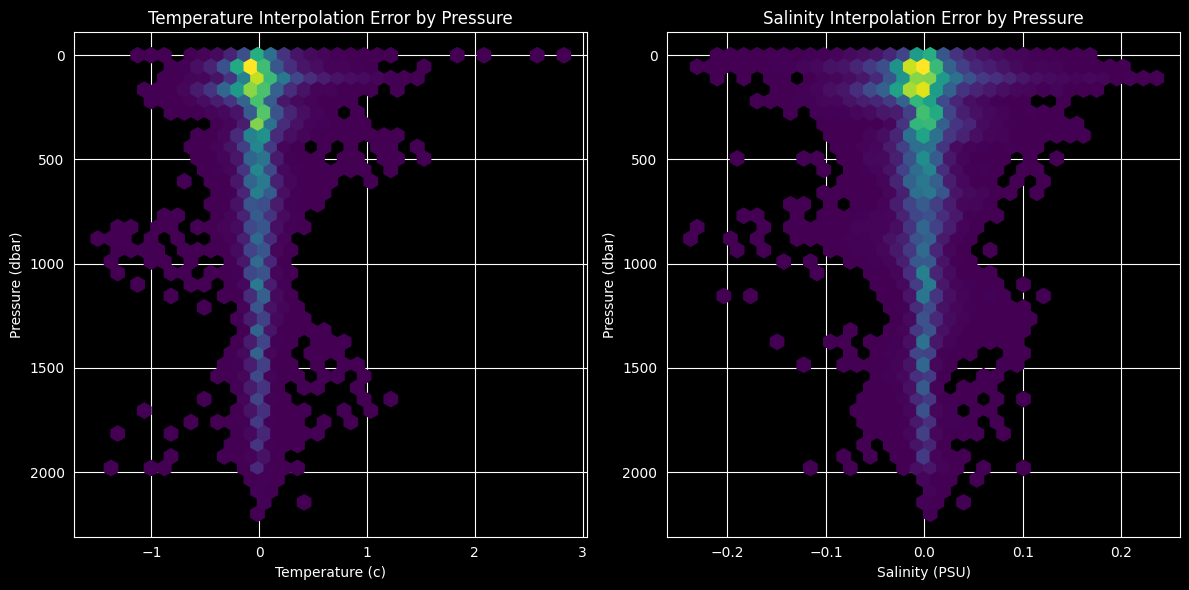

In [17]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 6))

ax[0].hexbin(error_records['temp_error'], error_records['pressure'], gridsize=35, mincnt=1, cmap='viridis')
ax[0].invert_yaxis()
ax[0].set(
    title=f"Temperature Interpolation Error by Pressure",
    xlabel=f"Temperature (c)",
    ylabel=f"Pressure (dbar)",
)

ax[1].hexbin(error_records['sal_error'], error_records['pressure'], gridsize=35, mincnt=1, cmap='viridis')
ax[1].invert_yaxis()
ax[1].set(
    title=f"Salinity Interpolation Error by Pressure",
    xlabel=f"Salinity (PSU)",
    ylabel=f"Pressure (dbar)",
)

fig.tight_layout()

### Interpretation

The hexbin plots reveal clear depth-structured patterns. Residuals are not uniformly distributed—error varies systematically with depth. Critically, aggregate central tendency remains near zero (mean temperature error 2.7×10⁻¹⁶°C, salinity -6.0×10⁻¹⁶ PSU), confirming no systematic bias for downstream spatio-temporal work.

Visual inspection suggests error density narrows in the deep ocean (below ~1500 dbar), consistent with the expectation that stable, low-gradient regions are easier to model. The thermocline region shows wider error spread, as expected for complex high-gradient structure.

This depth-error correlation suggests adaptive knot placement is concentrating effort appropriately: allocating flexibility where the water column is genuinely complex while staying sparse in simpler regimes. Formal quantification—stratifying residuals by local gradient strength—is deferred to future work but remains a priority for validating that the observed patterns match oceanographic expectations.

## 7. Method Scope and Current Limitations

**What this notebook demonstrates:**
- Proof-of-concept for adaptive spline representation of Argo profiles
- Validation framework via 5-fold cross-validation
- Uncertainty quantification combining sensor specs and model error
- Near-zero aggregate bias for spatio-temporal applications

**What this notebook does NOT address (yet):**
- **Comparative benchmarking**: No comparison to baselines (linear interpolation, uniform knots, PCHIP). We can't yet say if 0.175°C RMSE is good or merely adequate.
- **Failure modes**: The high-error tail (some cycles > 0.35°C RMSE) is unexplained. What profiles break this method?
- **Regional generalization**: Only tested on one subtropical box. Does this work in polar regions? Equatorial upwelling zones? Deep winter mixed layers?
- **SA-CT preservation**: Unlike MRST-PCHIP (Barker & McDougall, 2020), this method doesn't optimize for water-mass structure. Trade-offs are not quantified.
- **Parameter sensitivity**: Current settings were informally tuned. How sensitive are results to these choices?
- **Practical deployment**: Computational cost, workflow integration, and reproducibility details are not covered.

**Intended use**: This is a working prototype for exploring compact profile representation. Use cautiously, validate on your own data, and expect refinement. Not yet suitable as a black-box production tool.

## References

- Barker, P. M., & McDougall, T. J. (2020). Two interpolation methods using multiply-rotated piecewise cubic Hermite interpolating polynomials. *Journal of Atmospheric and Oceanic Technology, 37*(4), 605-619. https://doi.org/10.1175/JTECH-D-19-0211.1
- Li, W., Xu, S., Zhao, G., & Goh, L. P. (2005). Adaptive knot placement in B-spline curve approximation. *Computer-Aided Design, 37*(8), 791-797. https://doi.org/10.1016/j.cad.2004.09.008
- Müller, M., & Rügamer, D. (2025). Adaptive spline fitting with joint knot and smoothing parameter selection. *Journal of Computational and Graphical Statistics*. https://doi.org/10.1080/10618600.2025.2450458
- Wong, A. P. S., Keeley, R., Carval, T., & the Argo Data Management Team. (2025). *Argo Quality Control Manual for CTD and Trajectory Data* (Version 3.9). https://doi.org/10.13155/33951
- Yarger, D., Stoev, S., & Hsing, T. (2022). A functional-data approach to the Argo data. *The Annals of Applied Statistics, 16*(1), 216-246. https://doi.org/10.1214/21-AOAS1477

## Next Steps

This notebook establishes baseline performance for adaptive cycle-level representation. Immediate follow-on work includes:

1. **Comparative study**: Benchmark against PCHIP, Akima, and uniform-knot splines using the same validation framework
2. **Failure analysis**: Characterize the high-error tail—what's different about difficult profiles?
3. **Regional validation**: Test on Southern Ocean, equatorial Pacific, and Arctic data
4. **SA-CT diagnosis**: Quantify water-mass preservation trade-offs vs. MRST-PCHIP
5. **Parameter optimization**: Systematic grid search or Bayesian optimization for `CycleSettings`

The broader goal: integrate these cycle models into spatio-temporal interpolation workflows, where compact queryable representations with uncertainty become inputs to kriging or GP-based spatial prediction.